## Clasificador de Vinos con KNN
Entrena un modelo de K-Vecinos más Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus características químicas. ¿Podría una IA ayudarte a elegir un vino digno de sommelier?
La columna objetivo es label:

0 = Baja calidad

1 = Calidad media

2 = Alta calidad

### Importamos librerías y hacemos la ingesta de datos

In [110]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats.mstats import winsorize

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.datasets import make_regression
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import accuracy_score, accuracy_score,classification_report, confusion_matrix

from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [111]:
archivo = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(archivo, sep= ";")

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [113]:
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [114]:
# Audito el set como diccionario para tener una visión de posible limpieza

def audit_dataframe(df: pd.DataFrame) -> dict:
    info = {
        'filas': len(df),
        'cols': df.shape[1],
        'dtypes': df.dtypes.astype(str).to_dict(),
        'nulls': df.isnull().sum().sort_values(ascending=False).to_dict(),
        'nulls_pct': (df.isnull().mean().sort_values(ascending=False)*100).round(2).to_dict(),
        'duplicados': df[df.duplicated(keep=False)]
    }
    return info

audit = audit_dataframe(df)
audit


{'filas': 1599,
 'cols': 12,
 'dtypes': {'fixed acidity': 'float64',
  'volatile acidity': 'float64',
  'citric acid': 'float64',
  'residual sugar': 'float64',
  'chlorides': 'float64',
  'free sulfur dioxide': 'float64',
  'total sulfur dioxide': 'float64',
  'density': 'float64',
  'pH': 'float64',
  'sulphates': 'float64',
  'alcohol': 'float64',
  'quality': 'int64'},
 'nulls': {'fixed acidity': 0,
  'volatile acidity': 0,
  'citric acid': 0,
  'residual sugar': 0,
  'chlorides': 0,
  'free sulfur dioxide': 0,
  'total sulfur dioxide': 0,
  'density': 0,
  'pH': 0,
  'sulphates': 0,
  'alcohol': 0,
  'quality': 0},
 'nulls_pct': {'fixed acidity': 0.0,
  'volatile acidity': 0.0,
  'citric acid': 0.0,
  'residual sugar': 0.0,
  'chlorides': 0.0,
  'free sulfur dioxide': 0.0,
  'total sulfur dioxide': 0.0,
  'density': 0.0,
  'pH': 0.0,
  'sulphates': 0.0,
  'alcohol': 0.0,
  'quality': 0.0},
 'duplicados':       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides

### Defino tipo de variables y objetivo

In [115]:
# Todas son variables numéricas, aun así dejo definido

# Variables numéricas (int + float)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Variables categóricas (object + category)
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"las variables numéricas son: {num_cols}")
print(f"las variables categóricas son: {cat_cols}")

las variables numéricas son: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
las variables categóricas son: []


## Visualizaciones

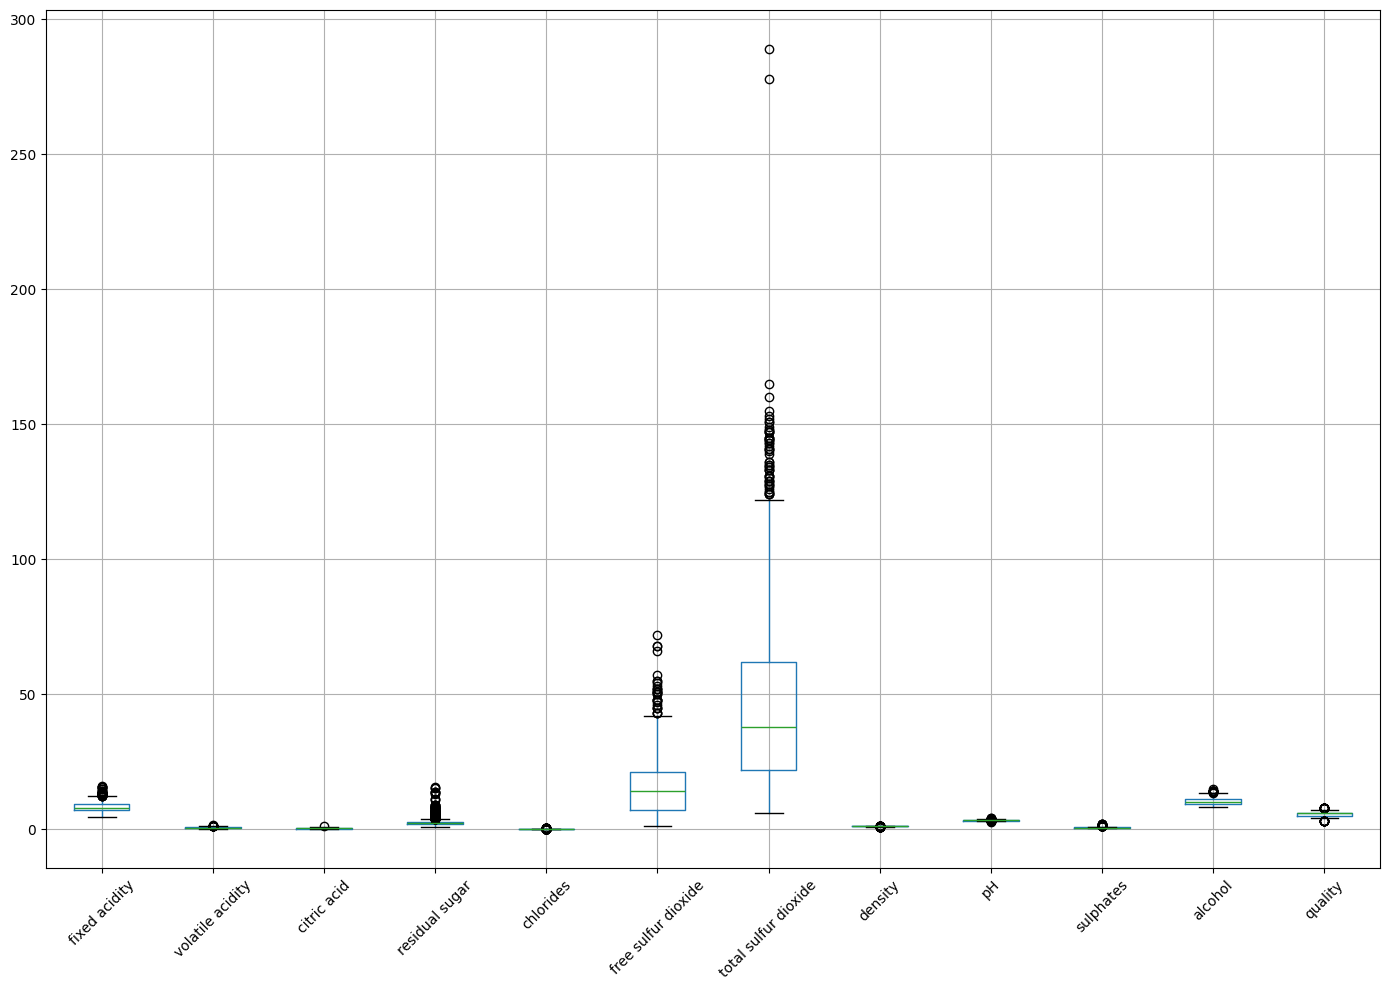

In [116]:
# Visualizo los outliers
plt.figure(figsize=(14, 10))
df.boxplot(rot=45)
plt.tight_layout()
plt.show()

Las variables relacionadas con el dióxido de azufre requieren control de outliers. Al ser un dataset pequeño opto por windsorizar para no eliminar datos sino sustituirlos

In [117]:
df["total sulfur dioxide"] = winsorize(df["total sulfur dioxide"], limits=[0.01, 0.01])
df["free sulfur dioxide"] = winsorize(df["free sulfur dioxide"], limits=[0.01, 0.01])
df["residual sugar"] = winsorize(df["residual sugar"], limits=[0.01, 0.01])

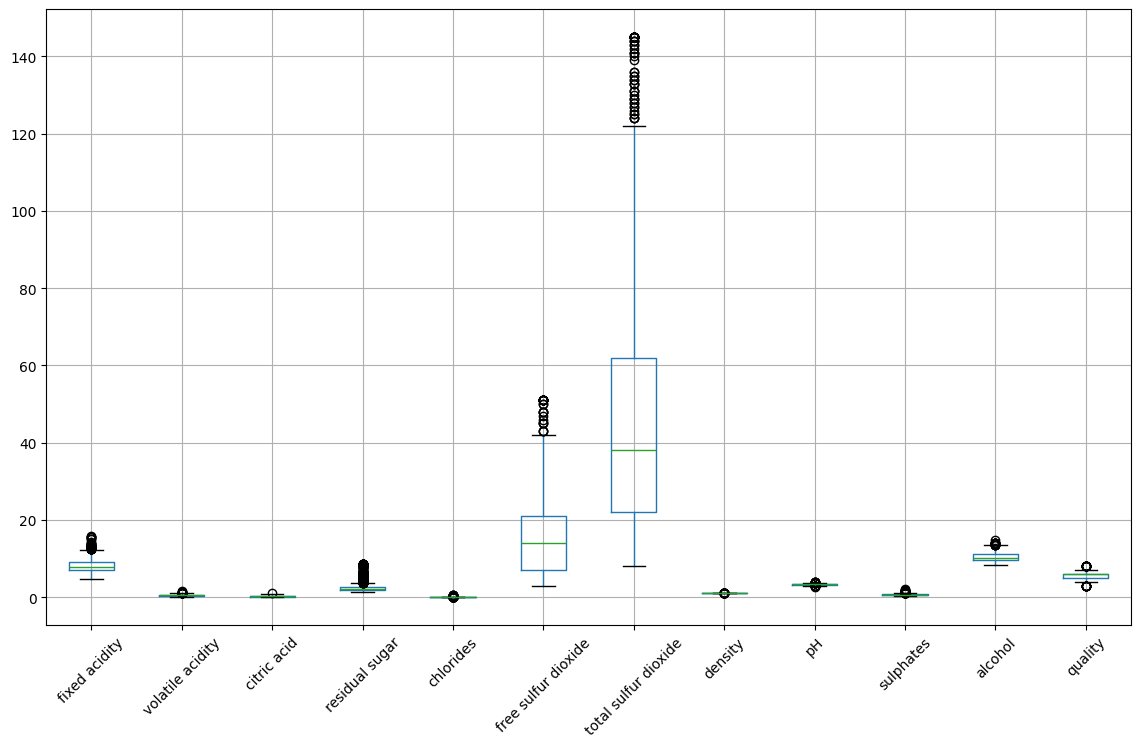

In [118]:
plt.figure(figsize=(14,8))
df.boxplot(rot=45)
plt.show()

### Split y entrenamiento

In [119]:
X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
493,8.7,0.690,0.31,3.0,0.086,23.0,81.0,1.00020,3.48,0.74,11.6
354,6.1,0.210,0.40,1.4,0.066,40.5,145.0,0.99120,3.25,0.59,11.9
342,10.9,0.390,0.47,1.8,0.118,6.0,14.0,0.99820,3.30,0.75,9.8
834,8.8,0.685,0.26,1.6,0.088,16.0,23.0,0.99694,3.32,0.47,9.4
705,8.4,1.035,0.15,6.0,0.073,11.0,54.0,0.99900,3.37,0.49,9.9


### Hago StandardScaler antes de aplicar el modelo KNN

In [120]:
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

In [121]:
# Hacemos un grid de hiperparámetros para los modelos

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 13], # Acceso al parámetro: Probamos distintos vecinos
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

In [122]:
grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)   # busco las variables más óptimas para el modelo

In [123]:
grid_knn.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [124]:
print("Mejores parámetros:", grid_knn.best_params_)
print("Mejor accuracy en CV:", grid_knn.best_score_)

Mejores parámetros: {'knn__metric': 'euclidean', 'knn__n_neighbors': 13, 'knn__weights': 'distance'}
Mejor accuracy en CV: 0.6654013480392157


In [125]:
# evaluación para test

best_knn = grid_knn.best_estimator_

y_pred = best_knn.predict(X_test)

print("Accuracy Test:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Test: 0.6625

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.73      0.72      0.73       130
           6       0.62      0.70      0.66       132
           7       0.61      0.60      0.60        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.34      0.33       320
weighted avg       0.63      0.66      0.65       320



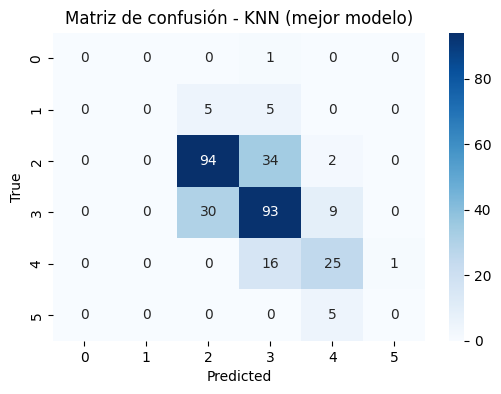

In [126]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Matriz de confusión - KNN (mejor modelo)")
plt.show()


El modelo KNN muestra un accuracy  del 0.66, aunque penalizado porque el dataset está desbalanceado en las clases. Las clases mayoritarias (5 y 6) se predicen de manera fiable, mientras que las clases con baja representatividad presentan recall bajo. El modelo es válido en general, pero no para precisión con las clases minoritarias

In [128]:
# ejemplo de uso:

def predict_wine_quality(model, values_list):
    columnas = [
        "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
        "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density",
        "pH", "sulphates", "alcohol"
    ]
    
    # Convertimos la entrada a un array
    x = np.array(values_list).reshape(1, -1)
    
    # Predicción
    pred = model.predict(x)[0]
    
    # Mensaje final
    if pred <= 4:
        return f"Este vino probablemente sea de calidad baja"
    elif pred <= 6:
        return f"Este vino probablemente sea de calidad media"
    else:
        return f"Este vino probablemente sea de buena calidad"

In [129]:
predict_wine_quality(
    best_knn,
    [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
)

'Este vino probablemente sea de calidad media'